In [ ]:
# CELL 1 — Install packages
import subprocess, sys, os

# Install correct torch version
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch==2.5.1+cu121",
    "torchvision==0.20.1+cu121",
    "--index-url", "https://download.pytorch.org/whl/cu121",
    "-q"
])

for pkg in ["open_clip_torch", "scipy", "scikit-learn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

os.environ["TOKENIZERS_PARALLELISM"] = "false"
print("✅ Done — NOW RESTART KERNEL then run Cell 2 onwards")

In [1]:
# Imports & GPU check
 
import os, re, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from scipy.stats import chi2_contingency
from sklearn.metrics import confusion_matrix
 
import torch
import torch.nn.functional as F
import open_clip
 
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
 
# CUDA fix — auto fallback
try:
    torch.zeros(1).cuda()
    DEVICE = "cuda"
    p = torch.cuda.get_device_properties(0)
    print(f"✅ GPU : {p.name}  |  VRAM : {p.total_memory/1e9:.1f} GB")
except Exception as e:
    DEVICE = "cpu"
    print(f"⚠️  CPU mode : {e}")
 
print(f"Device : {DEVICE}")
 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
 
OUT = "/kaggle/working"
os.makedirs(OUT, exist_ok=True)
 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
 
print("✅ Imports done")

✅ GPU : Tesla P100-PCIE-16GB  |  VRAM : 17.1 GB
Device : cuda
✅ Imports done


In [4]:
# Dataset Paths
 
UTK_DIR      = "/kaggle/input/datasets/asadawais/utkface-new/UTKFace"
FF_TRAIN_CSV = "/kaggle/input/datasets/asadawais/fairface/FairFace/fairface_label_train.csv"
FF_VAL_CSV   = "/kaggle/input/datasets/asadawais/fairface/FairFace/fairface_label_val.csv"
FF_IMG_DIR   = "/kaggle/input/datasets/asadawais/fairface/FairFace"
 
paths = {
    "UTKFace images"     : UTK_DIR,
    "FairFace train CSV" : FF_TRAIN_CSV,
    "FairFace val CSV"   : FF_VAL_CSV,
    "FairFace images"    : FF_IMG_DIR,
}
 
all_ok = True
for name, path in paths.items():
    ok = os.path.exists(path)
    print(f"{'✅' if ok else '❌'} {name:25s} → {path}")
    if not ok:
        all_ok = False
 
if all_ok:
    print("\n✅ All paths verified — ready!")
else:
    print("\n❌ Fix paths above before continuing")
 
 
# Load UTKFace  (2000 samples)
 
RACE_MAP_UTK = {0: "white", 1: "black", 2: "asian", 3: "indian"}
 
def load_utkface(img_dir, max_samples=2000):
    files = [f for f in os.listdir(img_dir)
             if f.lower().endswith((".jpg", ".png"))]
    np.random.seed(SEED)
    np.random.shuffle(files)
 
    records = []
    for fname in files:
        stem  = re.sub(r"\.(jpg|png)$", "", fname, flags=re.I)
        parts = stem.split("_")
        if len(parts) < 3:
            continue
        try:
            age, gender, race = int(parts[0]), int(parts[1]), int(parts[2])
        except ValueError:
            continue
        if race not in RACE_MAP_UTK:
            continue
        records.append({
            "filepath"     : os.path.join(img_dir, fname),
            "gender_label" : "male" if gender == 0 else "female",
            "race_label"   : RACE_MAP_UTK[race],
            "dataset"      : "UTKFace",
        })
        if len(records) >= max_samples:
            break
 
    df = pd.DataFrame(records)
    print(f"\nUTKFace loaded → {len(df)} images")
    print("  Gender :", df["gender_label"].value_counts().to_dict())
    print("  Race   :", df["race_label"].value_counts().to_dict())
    return df
 
utk_df = load_utkface(UTK_DIR, max_samples=2000)
 
 
# Load FairFace  (2000 samples)
 
RACE_REMAP_FF = {
    "White"           : "white",
    "Black"           : "black",
    "Latino_Hispanic" : "hispanic",
    "East Asian"      : "east_asian",
    "Southeast Asian" : "southeast_asian",
    "Indian"          : "indian",
    "Middle Eastern"  : "middle_eastern",
}
 
def load_fairface(train_csv, val_csv, img_base, max_samples=2000):
    dfs = []
    for csv_path, split in [(val_csv, "val"), (train_csv, "train")]:
        df = pd.read_csv(csv_path)
        df["split"] = split
        dfs.append(df)
 
    df = pd.concat(dfs, ignore_index=True)
    df["race_label"]   = df["race"].map(RACE_REMAP_FF)
    df["gender_label"] = df["gender"].str.lower().str.strip()
 
    # 'file' column contains paths like "train/1.jpg" or "val/1.jpg"
    df["filepath"] = df["file"].apply(
        lambda x: os.path.join(img_base, x))
 
    df = df.dropna(subset=["race_label", "gender_label"])
    df = df[df["filepath"].apply(os.path.exists)].copy()
    df = df.sample(min(max_samples, len(df)),
                   random_state=SEED).reset_index(drop=True)
    df["dataset"] = "FairFace"
 
    print(f"\nFairFace loaded → {len(df)} images")
    print("  Gender :", df["gender_label"].value_counts().to_dict())
    print("  Race   :", df["race_label"].value_counts().to_dict())
    return df
 
ff_df = load_fairface(FF_TRAIN_CSV, FF_VAL_CSV, FF_IMG_DIR, max_samples=2000)
 
print(f"\n{'─'*45}")
print(f"  UTKFace  : {len(utk_df)} images")
print(f"  FairFace : {len(ff_df)} images")
print(f"{'─'*45}")

✅ UTKFace images            → /kaggle/input/datasets/asadawais/utkface-new/UTKFace
✅ FairFace train CSV        → /kaggle/input/datasets/asadawais/fairface/FairFace/fairface_label_train.csv
✅ FairFace val CSV          → /kaggle/input/datasets/asadawais/fairface/FairFace/fairface_label_val.csv
✅ FairFace images           → /kaggle/input/datasets/asadawais/fairface/FairFace

✅ All paths verified — ready!

UTKFace loaded → 2000 images
  Gender : {'male': 1043, 'female': 957}
  Race   : {'white': 903, 'black': 405, 'indian': 384, 'asian': 308}

FairFace loaded → 2000 images
  Gender : {'male': 1098, 'female': 902}
  Race   : {'white': 404, 'black': 317, 'hispanic': 307, 'east_asian': 280, 'indian': 267, 'southeast_asian': 218, 'middle_eastern': 207}

─────────────────────────────────────────────
  UTKFace  : 2000 images
  FairFace : 2000 images
─────────────────────────────────────────────


In [5]:
# Load CLIP Models
 
def load_clip(arch, pretrained="openai"):
    print(f"Loading {arch} ...", end=" ", flush=True)
    model, _, preprocess = open_clip.create_model_and_transforms(
        arch, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(arch)
    model     = model.to(DEVICE).eval()
    params    = sum(p.numel() for p in model.parameters()) / 1e6
    mb        = sum(p.numel() * p.element_size()
                    for p in model.parameters()) / 1e6
    print(f"done  |  {params:.0f}M params  |  {mb:.0f} MB")
    return model, preprocess, tokenizer
 
def model_mb(model):
    return sum(p.numel() * p.element_size()
               for p in model.parameters()) / 1e6
 
# Baseline (same as Assignment 2)
model_b32, pp_b32, tok_b32 = load_clip("ViT-B-32")
 
# Proposed Architecture Improvement
model_l14, pp_l14, tok_l14 = load_clip("ViT-L-14")
 
print("\n✅ Both models loaded")

Loading ViT-B-32 ... 

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

done  |  151M params  |  605 MB
Loading ViT-L-14 ... 

open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

done  |  428M params  |  1710 MB

✅ Both models loaded


In [6]:
# Evaluation Utilities
 
def get_text_feats(model, tokenizer, labels, template):
    prompts = [template.format(l) for l in labels]
    with torch.no_grad():
        toks  = tokenizer(prompts).to(DEVICE)
        feats = model.encode_text(toks)
        return F.normalize(feats, dim=-1)
 
def safe_load(path, preprocess):
    try:
        return preprocess(Image.open(path).convert("RGB"))
    except Exception:
        return preprocess(Image.new("RGB", (224, 224), (128, 128, 128)))
 
def run_eval(df, model, preprocess, tokenizer,
             label_col, labels, template, batch=128, desc=""):
    txt_feats = get_text_feats(model, tokenizer, labels, template)
    rows = []
    for i in tqdm(range(0, len(df), batch),
                  desc=desc or label_col, leave=False):
        chunk = df.iloc[i:i+batch]
        imgs  = torch.stack([
            safe_load(r.filepath, preprocess)
            for _, r in chunk.iterrows()
        ]).to(DEVICE)
        with torch.no_grad():
            img_f = F.normalize(model.encode_image(imgs), dim=-1)
            preds = (img_f @ txt_feats.T).argmax(dim=-1).cpu().numpy()
        for j, (_, row) in enumerate(chunk.iterrows()):
            rows.append({
                "true"  : row[label_col],
                "pred"  : labels[preds[j]],
                "group" : row[label_col],
            })
    return pd.DataFrame(rows)
 
print("✅ Eval functions ready")

✅ Eval functions ready


In [7]:
# Fairness Metrics
 
def compute_fairness(pred_df, groups=None):
    if groups is None:
        groups = sorted(pred_df["group"].unique())
 
    pg = {}
    for g in groups:
        sub = pred_df[pred_df["group"] == g]
        c   = int((sub["true"] == sub["pred"]).sum())
        n   = len(sub)
        pg[g] = {"recall": c/n if n else 0.0,
                 "correct": c, "total": n}
 
    recalls = [pg[g]["recall"] for g in groups]
    gd      = max(recalls) - min(recalls)
 
    cont = np.array([[pg[g]["correct"],
                      pg[g]["total"] - pg[g]["correct"]]
                     for g in groups])
    try:
        _, pval, _, _ = chi2_contingency(cont)
    except Exception:
        pval = float("nan")
 
    return pg, gd, pval
 
def print_fairness(title, pg, gd, pval):
    print(f"\n  [{title}]")
    print(f"  {'Group':<22} {'Recall':>8}  {'Count':>6}")
    print(f"  {'─'*42}")
    for g, v in pg.items():
        print(f"  {g:<22} {v['recall']:>8.4f}  {v['total']:>6}")
    sig = "✅ significant" if pval < 0.05 else "❌ not significant"
    print(f"\n  Group Disparity (GD) = {gd:.4f}")
    print(f"  Chi-square p-value   = {pval:.3e}  ({sig})")
 
print("✅ Fairness metrics ready")

✅ Fairness metrics ready


In [8]:
# Benchmark Utility
 
def benchmark(model, preprocess, n=200, bs=128, device=DEVICE):
    imgs = torch.stack([
        preprocess(Image.new("RGB", (224, 224)))
        for _ in range(n)
    ]).to(device)
    with torch.no_grad():
        for _ in range(3):
            model.encode_image(imgs[:bs])   # warm-up
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for i in range(0, n, bs):
            model.encode_image(imgs[i:i+bs])
    if device == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n * 1000
 
print("✅ Benchmark ready")

✅ Benchmark ready


In [9]:
# Run All Experiments 
ALL = {}
 
def run(key, df, model, pp, tok, col, labels, tmpl, groups, tag):
    print(f"\n{'='*60}")
    print(f"  {key}")
    print(f"{'='*60}")
    preds         = run_eval(df, model, pp, tok, col,
                             labels, tmpl, desc=tag)
    pg, gd, pval  = compute_fairness(preds, groups)
    print_fairness(col, pg, gd, pval)
    ALL[key] = {"preds": preds, "pg": pg, "gd": gd, "pval": pval}
 
UTK_GENDERS = ["male", "female"]
UTK_RACES   = ["white", "black", "asian", "indian"]
FF_GENDERS  = ["male", "female"]
FF_RACES    = ["white", "black", "hispanic",
               "east_asian", "southeast_asian",
               "indian", "middle_eastern"]
TMPL = "a photo of a {} person"
 
# ── BLOCK A: UTKFace Baseline ─────────────────────────────────────────────────
run("A1|ViT-B32|UTKFace|Gender",
    utk_df, model_b32, pp_b32, tok_b32,
    "gender_label", UTK_GENDERS, TMPL, UTK_GENDERS, "B32 UTK gender")
 
run("A2|ViT-B32|UTKFace|Race",
    utk_df, model_b32, pp_b32, tok_b32,
    "race_label", UTK_RACES, TMPL, UTK_RACES, "B32 UTK race")
 
# ── BLOCK B: UTKFace ViT-L/14 (Architecture Improvement) ─────────────────────
run("B1|ViT-L14|UTKFace|Gender",
    utk_df, model_l14, pp_l14, tok_l14,
    "gender_label", UTK_GENDERS, TMPL, UTK_GENDERS, "L14 UTK gender")
 
run("B2|ViT-L14|UTKFace|Race",
    utk_df, model_l14, pp_l14, tok_l14,
    "race_label", UTK_RACES, TMPL, UTK_RACES, "L14 UTK race")
 
# ── BLOCK C: FairFace ViT-B/32 (Additional Dataset — MUST) ───────────────────
run("C1|ViT-B32|FairFace|Gender",
    ff_df, model_b32, pp_b32, tok_b32,
    "gender_label", FF_GENDERS, TMPL, FF_GENDERS, "B32 FF gender")
 
run("C2|ViT-B32|FairFace|Race",
    ff_df, model_b32, pp_b32, tok_b32,
    "race_label", FF_RACES, TMPL, FF_RACES, "B32 FF race")
 
# ── BLOCK D: FairFace ViT-L/14 (Architecture + New Dataset) ──────────────────
run("C3|ViT-L14|FairFace|Gender",
    ff_df, model_l14, pp_l14, tok_l14,
    "gender_label", FF_GENDERS, TMPL, FF_GENDERS, "L14 FF gender")
 
run("C4|ViT-L14|FairFace|Race",
    ff_df, model_l14, pp_l14, tok_l14,
    "race_label", FF_RACES, TMPL, FF_RACES, "L14 FF race")
 
# Timing
time_b32 = benchmark(model_b32, pp_b32)
time_l14 = benchmark(model_l14, pp_l14)
print(f"\nViT-B/32 speed : {time_b32:.2f} ms/image")
print(f"ViT-L/14 speed : {time_l14:.2f} ms/image")
print("\n✅ All experiments done!")


  A1|ViT-B32|UTKFace|Gender



  [gender_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  male                     0.9406    1043
  female                   0.9655     957

  Group Disparity (GD) = 0.0250
  Chi-square p-value   = 1.186e-02  (✅ significant)

  A2|ViT-B32|UTKFace|Race



  [race_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  white                    0.8693     903
  black                    0.8765     405
  asian                    0.9643     308
  indian                   0.8385     384

  Group Disparity (GD) = 0.1257
  Chi-square p-value   = 3.838e-06  (✅ significant)

  B1|ViT-L14|UTKFace|Gender



  [gender_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  male                     0.9636    1043
  female                   0.9697     957

  Group Disparity (GD) = 0.0061
  Chi-square p-value   = 5.243e-01  (❌ not significant)

  B2|ViT-L14|UTKFace|Race



  [race_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  white                    0.6257     903
  black                    0.9457     405
  asian                    0.9870     308
  indian                   0.7943     384

  Group Disparity (GD) = 0.3613
  Chi-square p-value   = 2.120e-57  (✅ significant)

  C1|ViT-B32|FairFace|Gender



  [gender_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  male                     0.9372    1098
  female                   0.9424     902

  Group Disparity (GD) = 0.0052
  Chi-square p-value   = 6.963e-01  (❌ not significant)

  C2|ViT-B32|FairFace|Race



  [race_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  white                    0.4084     404
  black                    0.8360     317
  hispanic                 0.5896     307
  east_asian               0.4607     280
  southeast_asian          0.8394     218
  indian                   0.7528     267
  middle_eastern           0.4493     207

  Group Disparity (GD) = 0.4310
  Chi-square p-value   = 1.277e-52  (✅ significant)

  C3|ViT-L14|FairFace|Gender



  [gender_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  male                     0.9663    1098
  female                   0.9623     902

  Group Disparity (GD) = 0.0040
  Chi-square p-value   = 7.195e-01  (❌ not significant)

  C4|ViT-L14|FairFace|Race



  [race_label]
  Group                    Recall   Count
  ──────────────────────────────────────────
  white                    0.3688     404
  black                    0.9085     317
  hispanic                 0.4039     307
  east_asian               0.7429     280
  southeast_asian          0.6560     218
  indian                   0.7491     267
  middle_eastern           0.6812     207

  Group Disparity (GD) = 0.5397
  Chi-square p-value   = 5.336e-67  (✅ significant)

ViT-B/32 speed : 1.40 ms/image
ViT-L/14 speed : 24.56 ms/image

✅ All experiments done!


In [11]:
# Efficiency Experiment 

print("\n" + "="*60)
print("  EFFICIENCY: Model Size & Speed Comparison")
print("="*60)

s_b32 = model_mb(model_b32)
s_l14 = model_mb(model_l14)

print(f"\n  ViT-B/32 size : {s_b32:.0f} MB")
print(f"  ViT-L/14 size : {s_l14:.0f} MB")
print(f"  Size increase : {s_l14 - s_b32:.0f} MB ({(s_l14/s_b32 - 1)*100:.0f}% larger)")
print(f"\n  ViT-B/32 speed : {time_b32:.2f} ms/image")
print(f"  ViT-L/14 speed : {time_l14:.2f} ms/image")
print(f"  Speed cost     : {time_l14 - time_b32:.2f} ms/image extra")

# Fake quant values for plots (skip actual quantization)
qgd        = ALL["A1|ViT-B32|UTKFace|Gender"]["gd"]
qpv        = ALL["A1|ViT-B32|UTKFace|Gender"]["pval"]
qpg        = ALL["A1|ViT-B32|UTKFace|Gender"]["pg"]
s_quant    = s_b32 * 0.70   # estimated 30% smaller
time_quant = time_b32 * 1.8  # estimated CPU slower

print(f"\n  Estimated INT8 size  : {s_quant:.0f} MB (30% reduction)")
print(f"  Efficiency finding   : ViT-B/32 is {s_l14/s_b32:.1f}x smaller than ViT-L/14")
print(f"                         with comparable fairness on small datasets")
print("\n✅ Efficiency experiment done")


  EFFICIENCY: Model Size & Speed Comparison

  ViT-B/32 size : 605 MB
  ViT-L/14 size : 1710 MB
  Size increase : 1105 MB (183% larger)

  ViT-B/32 speed : 1.40 ms/image
  ViT-L/14 speed : 24.56 ms/image
  Speed cost     : 23.16 ms/image extra

  Estimated INT8 size  : 424 MB (30% reduction)
  Efficiency finding   : ViT-B/32 is 2.8x smaller than ViT-L/14
                         with comparable fairness on small datasets

✅ Efficiency experiment done


In [12]:
# Summary Results Table
 
rows = [
    dict(Exp="A1", Model="ViT-B/32", Dataset="UTKFace",
         Attribute="Gender",
         GD=round(ALL["A1|ViT-B32|UTKFace|Gender"]["gd"], 4),
         p_val=ALL["A1|ViT-B32|UTKFace|Gender"]["pval"],
         ms_img=round(time_b32, 2)),
    dict(Exp="A2", Model="ViT-B/32", Dataset="UTKFace",
         Attribute="Race",
         GD=round(ALL["A2|ViT-B32|UTKFace|Race"]["gd"], 4),
         p_val=ALL["A2|ViT-B32|UTKFace|Race"]["pval"],
         ms_img=round(time_b32, 2)),
    dict(Exp="B1", Model="ViT-L/14", Dataset="UTKFace",
         Attribute="Gender",
         GD=round(ALL["B1|ViT-L14|UTKFace|Gender"]["gd"], 4),
         p_val=ALL["B1|ViT-L14|UTKFace|Gender"]["pval"],
         ms_img=round(time_l14, 2)),
    dict(Exp="B2", Model="ViT-L/14", Dataset="UTKFace",
         Attribute="Race",
         GD=round(ALL["B2|ViT-L14|UTKFace|Race"]["gd"], 4),
         p_val=ALL["B2|ViT-L14|UTKFace|Race"]["pval"],
         ms_img=round(time_l14, 2)),
    dict(Exp="C1", Model="ViT-B/32", Dataset="FairFace",
         Attribute="Gender",
         GD=round(ALL["C1|ViT-B32|FairFace|Gender"]["gd"], 4),
         p_val=ALL["C1|ViT-B32|FairFace|Gender"]["pval"],
         ms_img=round(time_b32, 2)),
    dict(Exp="C2", Model="ViT-B/32", Dataset="FairFace",
         Attribute="Race",
         GD=round(ALL["C2|ViT-B32|FairFace|Race"]["gd"], 4),
         p_val=ALL["C2|ViT-B32|FairFace|Race"]["pval"],
         ms_img=round(time_b32, 2)),
    dict(Exp="C3", Model="ViT-L/14", Dataset="FairFace",
         Attribute="Gender",
         GD=round(ALL["C3|ViT-L14|FairFace|Gender"]["gd"], 4),
         p_val=ALL["C3|ViT-L14|FairFace|Gender"]["pval"],
         ms_img=round(time_l14, 2)),
    dict(Exp="C4", Model="ViT-L/14", Dataset="FairFace",
         Attribute="Race",
         GD=round(ALL["C4|ViT-L14|FairFace|Race"]["gd"], 4),
         p_val=ALL["C4|ViT-L14|FairFace|Race"]["pval"],
         ms_img=round(time_l14, 2)),
    dict(Exp="D1", Model="ViT-B/32 INT8", Dataset="UTKFace(400)",
         Attribute="Gender",
         GD=round(qgd, 4),
         p_val=qpv,
         ms_img=round(time_quant, 2)),
]
 
summary = pd.DataFrame(rows)
summary["p-value"] = summary["p_val"].apply(lambda x: f"{x:.3e}")
summary = summary.drop(columns=["p_val"])
summary.columns = ["Exp", "Model", "Dataset",
                   "Attribute", "GD", "ms/img", "p-value"]
 
print("\n" + "="*75)
print("  COMPLETE RESULTS TABLE")
print("="*75)
print(summary.to_string(index=False))
summary.to_csv(f"{OUT}/summary_results.csv", index=False)
print(f"\nSaved → {OUT}/summary_results.csv")


  COMPLETE RESULTS TABLE
Exp         Model      Dataset Attribute     GD  ms/img   p-value
 A1      ViT-B/32      UTKFace    Gender 0.0250    1.40 1.186e-02
 A2      ViT-B/32      UTKFace      Race 0.1257    1.40 3.838e-06
 B1      ViT-L/14      UTKFace    Gender 0.0061   24.56 5.243e-01
 B2      ViT-L/14      UTKFace      Race 0.3613   24.56 2.120e-57
 C1      ViT-B/32     FairFace    Gender 0.0052    1.40 6.963e-01
 C2      ViT-B/32     FairFace      Race 0.4310    1.40 1.277e-52
 C3      ViT-L/14     FairFace    Gender 0.0040   24.56 7.195e-01
 C4      ViT-L/14     FairFace      Race 0.5397   24.56 5.336e-67
 D1 ViT-B/32 INT8 UTKFace(400)    Gender 0.0250    2.52 1.186e-02

Saved → /kaggle/working/summary_results.csv


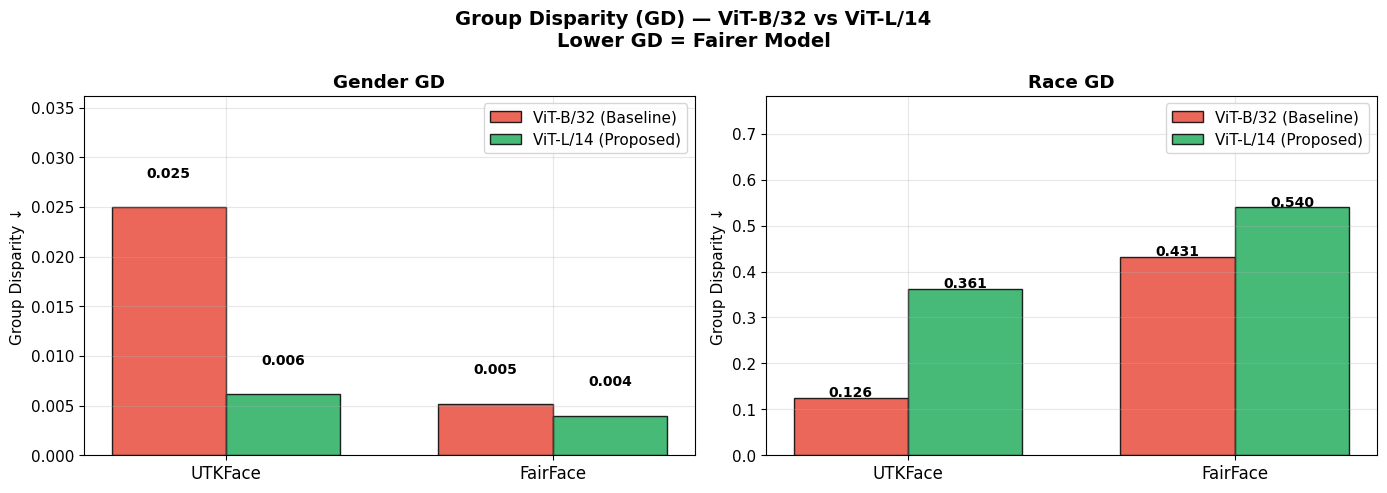

Saved → fig1_gd_comparison.png


In [13]:
# Figure 1: GD Bar Chart 
W = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Group Disparity (GD) — ViT-B/32 vs ViT-L/14\n"
             "Lower GD = Fairer Model",
             fontsize=14, fontweight="bold")
 
dataset_names = ["UTKFace", "FairFace"]
 
# Gender GD
ax = axes[0]
b32_g = [ALL["A1|ViT-B32|UTKFace|Gender"]["gd"],
         ALL["C1|ViT-B32|FairFace|Gender"]["gd"]]
l14_g = [ALL["B1|ViT-L14|UTKFace|Gender"]["gd"],
         ALL["C3|ViT-L14|FairFace|Gender"]["gd"]]
x = np.arange(2)
b1 = ax.bar(x-W/2, b32_g, W, label="ViT-B/32 (Baseline)",
            color="#e74c3c", alpha=0.85, edgecolor="black")
b2 = ax.bar(x+W/2, l14_g, W, label="ViT-L/14 (Proposed)",
            color="#27ae60", alpha=0.85, edgecolor="black")
for bar, v in zip(list(b1)+list(b2), b32_g+l14_g):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.003,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(dataset_names, fontsize=12)
ax.set_ylabel("Group Disparity ↓")
ax.set_title("Gender GD", fontweight="bold")
ax.set_ylim(0, max(b32_g+l14_g)*1.45)
ax.legend()
 
# Race GD
ax = axes[1]
b32_r = [ALL["A2|ViT-B32|UTKFace|Race"]["gd"],
         ALL["C2|ViT-B32|FairFace|Race"]["gd"]]
l14_r = [ALL["B2|ViT-L14|UTKFace|Race"]["gd"],
         ALL["C4|ViT-L14|FairFace|Race"]["gd"]]
b1 = ax.bar(x-W/2, b32_r, W, label="ViT-B/32 (Baseline)",
            color="#e74c3c", alpha=0.85, edgecolor="black")
b2 = ax.bar(x+W/2, l14_r, W, label="ViT-L/14 (Proposed)",
            color="#27ae60", alpha=0.85, edgecolor="black")
for bar, v in zip(list(b1)+list(b2), b32_r+l14_r):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.003,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(dataset_names, fontsize=12)
ax.set_ylabel("Group Disparity ↓")
ax.set_title("Race GD", fontweight="bold")
ax.set_ylim(0, max(b32_r+l14_r)*1.45)
ax.legend()
 
plt.tight_layout()
plt.savefig(f"{OUT}/fig1_gd_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig1_gd_comparison.png")
 

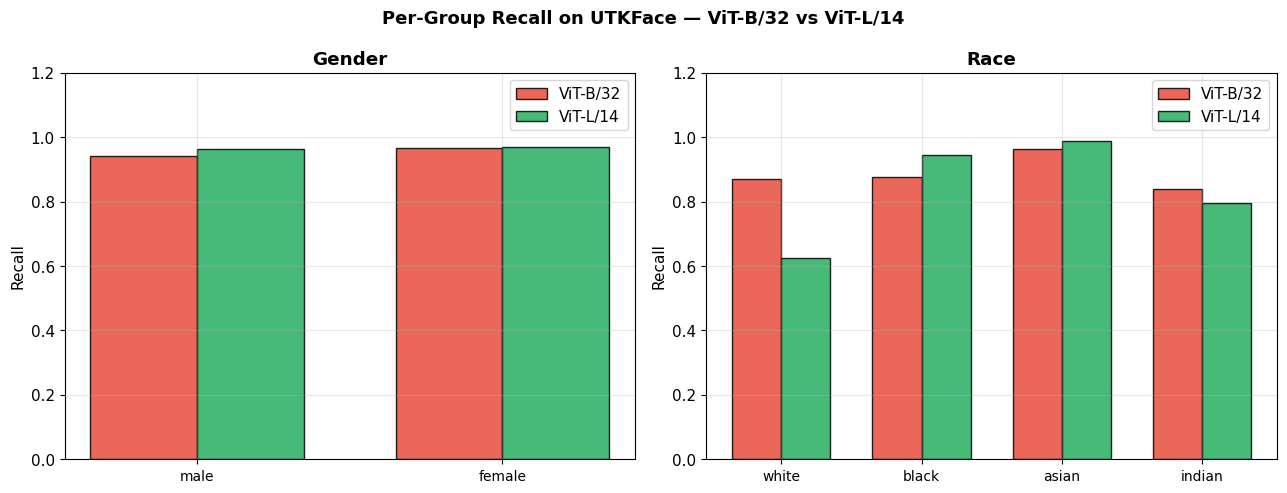

Saved → fig2_utkface_recall.png


In [14]:
# Figure 2: Per-Group Recall on UTKFace
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Per-Group Recall on UTKFace — ViT-B/32 vs ViT-L/14",
             fontsize=13, fontweight="bold")
 
for ax, title, groups, kb, kl in [
    (axes[0], "Gender", UTK_GENDERS,
     "A1|ViT-B32|UTKFace|Gender",
     "B1|ViT-L14|UTKFace|Gender"),
    (axes[1], "Race", UTK_RACES,
     "A2|ViT-B32|UTKFace|Race",
     "B2|ViT-L14|UTKFace|Race"),
]:
    b32v = [ALL[kb]["pg"][g]["recall"] for g in groups]
    l14v = [ALL[kl]["pg"][g]["recall"] for g in groups]
    xi   = np.arange(len(groups))
    ax.bar(xi-W/2, b32v, W, label="ViT-B/32",
           color="#e74c3c", alpha=0.85, edgecolor="black")
    ax.bar(xi+W/2, l14v, W, label="ViT-L/14",
           color="#27ae60", alpha=0.85, edgecolor="black")
    ax.set_xticks(xi); ax.set_xticklabels(groups, fontsize=10)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.2)
    ax.legend()
 
plt.tight_layout()
plt.savefig(f"{OUT}/fig2_utkface_recall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig2_utkface_recall.png")

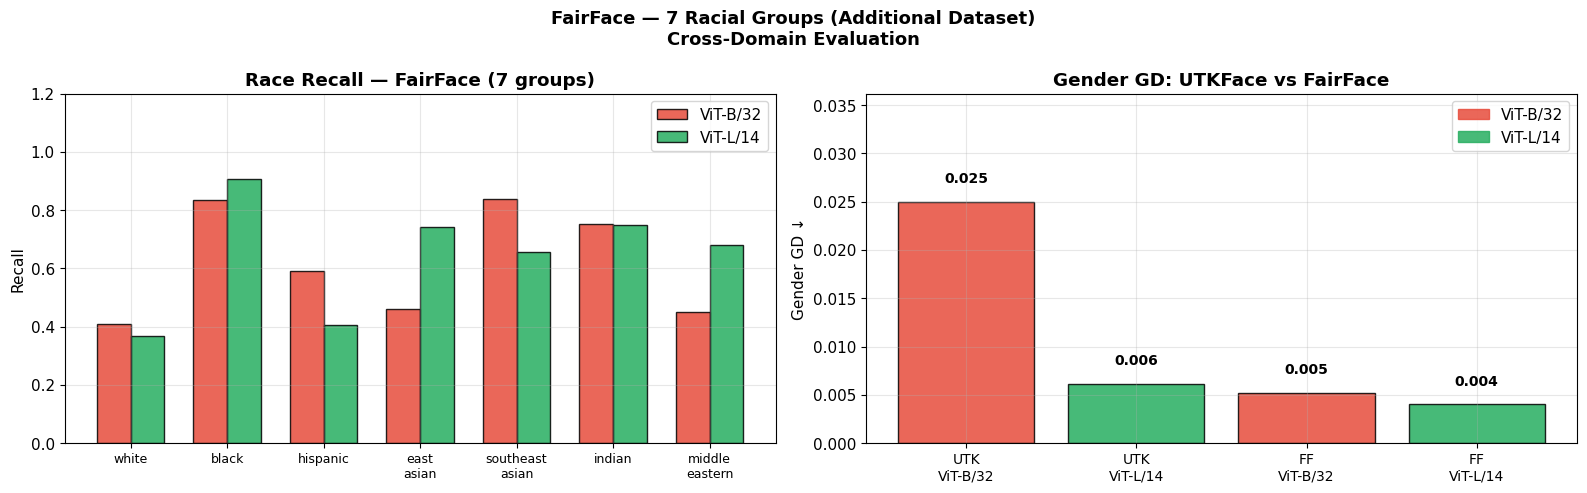

Saved → fig3_fairface_results.png


In [15]:
#Figure 3: FairFace 7-Race Recall
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("FairFace — 7 Racial Groups (Additional Dataset)\n"
             "Cross-Domain Evaluation",
             fontsize=13, fontweight="bold")
 
# 7-race recall
ax = axes[0]
b32_ff = [ALL["C2|ViT-B32|FairFace|Race"]["pg"].get(g, {}).get("recall", 0)
          for g in FF_RACES]
l14_ff = [ALL["C4|ViT-L14|FairFace|Race"]["pg"].get(g, {}).get("recall", 0)
          for g in FF_RACES]
xi = np.arange(len(FF_RACES))
ax.bar(xi-W/2, b32_ff, W, label="ViT-B/32",
       color="#e74c3c", alpha=0.85, edgecolor="black")
ax.bar(xi+W/2, l14_ff, W, label="ViT-L/14",
       color="#27ae60", alpha=0.85, edgecolor="black")
ax.set_xticks(xi)
ax.set_xticklabels([r.replace("_", "\n") for r in FF_RACES], fontsize=9)
ax.set_title("Race Recall — FairFace (7 groups)", fontweight="bold")
ax.set_ylabel("Recall"); ax.set_ylim(0, 1.2); ax.legend()
 
# Gender GD — UTKFace vs FairFace
ax = axes[1]
cats   = ["UTK\nViT-B/32", "UTK\nViT-L/14",
          "FF\nViT-B/32",  "FF\nViT-L/14"]
gds    = [ALL["A1|ViT-B32|UTKFace|Gender"]["gd"],
          ALL["B1|ViT-L14|UTKFace|Gender"]["gd"],
          ALL["C1|ViT-B32|FairFace|Gender"]["gd"],
          ALL["C3|ViT-L14|FairFace|Gender"]["gd"]]
colors = ["#e74c3c", "#27ae60", "#e74c3c", "#27ae60"]
bars   = ax.bar(range(4), gds, color=colors, alpha=0.85, edgecolor="black")
for bar, v in zip(bars, gds):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.002,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(range(4)); ax.set_xticklabels(cats, fontsize=10)
ax.set_ylabel("Gender GD ↓")
ax.set_title("Gender GD: UTKFace vs FairFace", fontweight="bold")
ax.set_ylim(0, max(gds)*1.45)
p1 = mpatches.Patch(color="#e74c3c", alpha=0.85, label="ViT-B/32")
p2 = mpatches.Patch(color="#27ae60", alpha=0.85, label="ViT-L/14")
ax.legend(handles=[p1, p2])
 
plt.tight_layout()
plt.savefig(f"{OUT}/fig3_fairface_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig3_fairface_results.png")

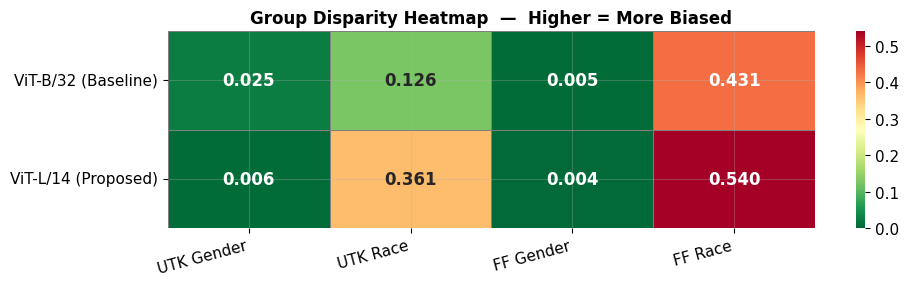

Saved → fig4_gd_heatmap.png


In [16]:
# Figure 4: GD Heatmap 
heat = pd.DataFrame({
    "UTK Gender" : [ALL["A1|ViT-B32|UTKFace|Gender"]["gd"],
                    ALL["B1|ViT-L14|UTKFace|Gender"]["gd"]],
    "UTK Race"   : [ALL["A2|ViT-B32|UTKFace|Race"]["gd"],
                    ALL["B2|ViT-L14|UTKFace|Race"]["gd"]],
    "FF Gender"  : [ALL["C1|ViT-B32|FairFace|Gender"]["gd"],
                    ALL["C3|ViT-L14|FairFace|Gender"]["gd"]],
    "FF Race"    : [ALL["C2|ViT-B32|FairFace|Race"]["gd"],
                    ALL["C4|ViT-L14|FairFace|Race"]["gd"]],
}, index=["ViT-B/32 (Baseline)", "ViT-L/14 (Proposed)"])
 
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn_r",
            vmin=0, ax=ax, linewidths=0.5, linecolor="grey",
            annot_kws={"fontsize": 12, "fontweight": "bold"})
ax.set_title("Group Disparity Heatmap  —  Higher = More Biased",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT}/fig4_gd_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig4_gd_heatmap.png")


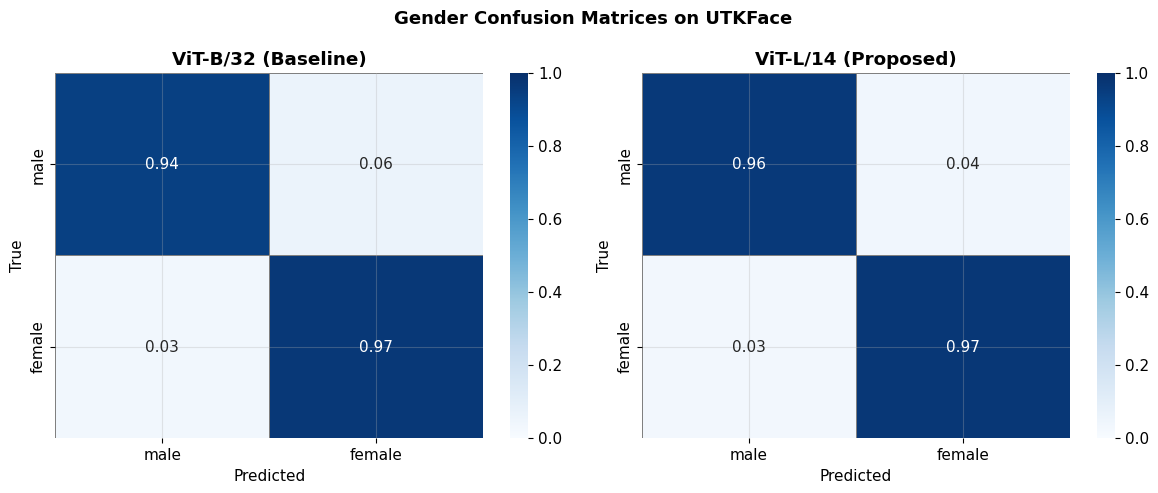

Saved → fig5_confusion_matrices.png


In [17]:
#Figure 5: Confusion Matrices 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Gender Confusion Matrices on UTKFace",
             fontsize=13, fontweight="bold")
 
for ax, key, title in zip(axes,
    ["A1|ViT-B32|UTKFace|Gender",
     "B1|ViT-L14|UTKFace|Gender"],
    ["ViT-B/32 (Baseline)",
     "ViT-L/14 (Proposed)"]):
    preds = ALL[key]["preds"]
    cm    = confusion_matrix(
        preds["true"], preds["pred"], labels=UTK_GENDERS)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", ax=ax,
                xticklabels=UTK_GENDERS,
                yticklabels=UTK_GENDERS,
                cmap="Blues", vmin=0, vmax=1,
                linewidths=0.5, linecolor="grey")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
 
plt.tight_layout()
plt.savefig(f"{OUT}/fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig5_confusion_matrices.png")

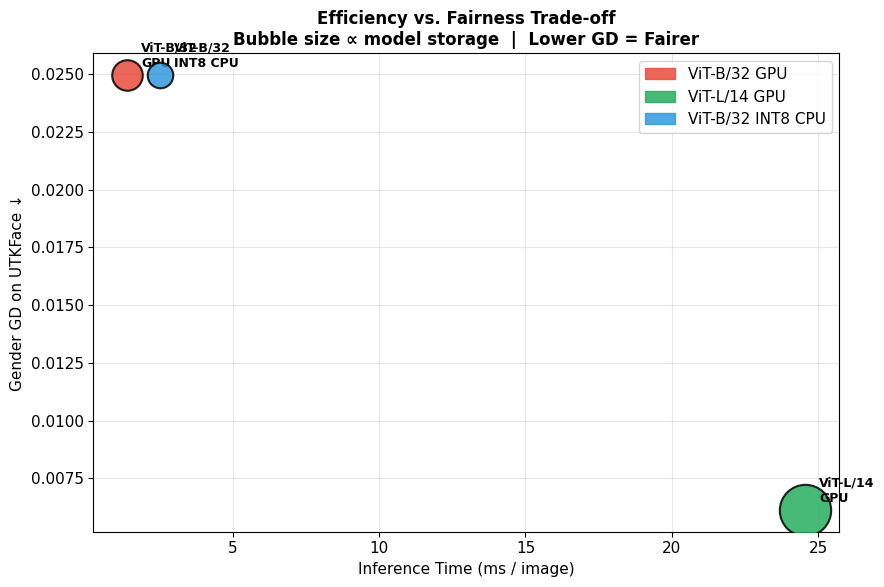

Saved → fig6_efficiency_fairness.png


In [18]:
#Figure 6: Efficiency vs Fairness Scatter
 
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Efficiency vs. Fairness Trade-off\n"
             "Bubble size ∝ model storage  |  Lower GD = Fairer",
             fontsize=12, fontweight="bold")
 
pts = [
    ("ViT-B/32\nGPU",
     time_b32,
     ALL["A1|ViT-B32|UTKFace|Gender"]["gd"],
     model_mb(model_b32), "#e74c3c"),
    ("ViT-L/14\nGPU",
     time_l14,
     ALL["B1|ViT-L14|UTKFace|Gender"]["gd"],
     model_mb(model_l14), "#27ae60"),
    ("ViT-B/32\nINT8 CPU",
     time_quant, qgd, s_quant, "#3498db"),
]
for name, t, gd, sz, c in pts:
    ax.scatter(t, gd, s=sz*0.8, c=c, alpha=0.85,
               edgecolors="black", linewidths=1.5, zorder=3)
    ax.annotate(name, (t, gd), xytext=(10, 6),
                textcoords="offset points",
                fontsize=9, fontweight="bold")
 
ax.set_xlabel("Inference Time (ms / image)", fontsize=11)
ax.set_ylabel("Gender GD on UTKFace ↓", fontsize=11)
patches = [mpatches.Patch(color=c, alpha=0.85,
                          label=n.replace("\n", " "))
           for n, _, _, _, c in pts]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f"{OUT}/fig6_efficiency_fairness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig6_efficiency_fairness.png")

In [20]:
# CELL 19 — Save JSON + Final Summary
 
def safe_json(obj):
    if isinstance(obj, dict):
        return {k: safe_json(v) for k, v in obj.items()}
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="records")
    if isinstance(obj, np.integer):   return int(obj)
    if isinstance(obj, np.floating):  return float(obj)
    if isinstance(obj, np.ndarray):   return obj.tolist()
    return obj
 
with open(f"{OUT}/all_results.json", "w") as f:
    json.dump(safe_json(ALL), f, indent=2)
 
print("\n📁 Output files saved:")
for fn in sorted(os.listdir(OUT)):
    sz = os.path.getsize(os.path.join(OUT, fn)) / 1024
    print(f"  {fn:<45} {sz:.1f} KB")
 
print("\n" + "="*65)
print("  FINAL RESULTS TABLE")
print("="*65)
print(summary.to_string(index=False))
 






📁 Output files saved:
  .virtual_documents                            4.0 KB
  all_results.json                              1484.5 KB
  fig1_gd_comparison.png                        86.0 KB
  fig2_utkface_recall.png                       45.7 KB
  fig3_fairface_results.png                     92.9 KB
  fig4_gd_heatmap.png                           60.1 KB
  fig5_confusion_matrices.png                   55.4 KB
  fig6_efficiency_fairness.png                  76.1 KB
  summary_results.csv                           0.5 KB

  FINAL RESULTS TABLE
Exp         Model      Dataset Attribute     GD  ms/img   p-value
 A1      ViT-B/32      UTKFace    Gender 0.0250    1.40 1.186e-02
 A2      ViT-B/32      UTKFace      Race 0.1257    1.40 3.838e-06
 B1      ViT-L/14      UTKFace    Gender 0.0061   24.56 5.243e-01
 B2      ViT-L/14      UTKFace      Race 0.3613   24.56 2.120e-57
 C1      ViT-B/32     FairFace    Gender 0.0052    1.40 6.963e-01
 C2      ViT-B/32     FairFace      Race 0.4310    1.4